# Driver-Gene Benchmark.

## 1. Configuration

In [ ]:
import os
import csv
import json
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import dgl

from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.cluster import KMeans
from scipy.stats import spearmanr

import plotly.graph_objects as go

# Your existing project imports.
# Adjust this import if your project keeps these functions in another module.
from utils import choose_model, load_graph_data, load_oncokb_genes

warnings.filterwarnings("ignore")

# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "../data"
OUTPUT_DIR = "results/gene_prediction/12_model_heldout_benchmark"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NET_TYPE = "ppnet"  # e.g. ppnet / pathnet / ggnet
DATA_FILE = os.path.join(
    DATA_ROOT,
    f"{NET_TYPE}_omics_filtered_combined_gene_embeddings_32x4.json"
)

# Use either OnGene or OncoKB as an external candidate list.
REFERENCE_NAME = "OnGene"
REFERENCE_FILE = os.path.join(DATA_ROOT, "ongene_803.txt")

# -----------------------------
# Models requested by you
# -----------------------------
MODEL_CHOICES = [
    "HGDC", "EMOGI", "MOGAT", "DMGNN", "Chebnet",
    "MTGCN", "ATTAG", "GIN", "GraphSAGE", "GAT", "GCN"
]

# -----------------------------
# Training settings
# -----------------------------
HIDDEN_FEATS = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
WEIGHT_DECAY = 0.0
SEED = 42

# 10 folds × 2 repeats = 20 held-out evaluations per model.
N_SPLITS = 5
N_REPEATS = 1
N_FOLDS_TOTAL = N_SPLITS * N_REPEATS

# Keep only five paired ROC/PR curves globally after all model-fold runs.
TOP_N_CURVE_PAIRS = 10

# Requested plotting condition.
PLOT_ONLY_IF_ATTAG_BEST = True

# Sankey controls.
SANKEY_TOP_GENES = 100
SANKEY_TOP_NEIGHBORS = 5
SANKEY_N_CLUSTERS = 12

# Reproducibility.
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Network: {NET_TYPE}")
print(f"Models: {len(MODEL_CHOICES)}")
print(f"Held-out folds/model: {N_FOLDS_TOTAL} = {N_SPLITS} folds × {N_REPEATS} repeats")
print(f"Output: {os.path.abspath(OUTPUT_DIR)}")

Device: cpu
Network: ppnet
Models: 12
Held-out folds/model: 5 = 5 folds × 1 repeats
Output: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/attag/results/gene_prediction/12_model_heldout_benchmark


## 2. Load graph, embeddings, and original labels

The original labels are preserved exactly. In particular, originally unlabeled genes (`-1`) are **not** relabeled to `1` because they appear in an external OnGene/OncoKB list.

In [23]:
nodes, edges, embeddings, labels = load_graph_data(DATA_FILE)
reference_genes = set(load_oncokb_genes(REFERENCE_FILE))

node_names = list(nodes.keys())
name_to_index = {name: i for i, name in enumerate(node_names)}

X_np = np.asarray(embeddings, dtype=np.float32)
y_np = np.asarray(labels, dtype=np.int64).copy()

if len(node_names) != len(X_np) or len(node_names) != len(y_np):
    raise ValueError(
        f"Node/feature/label mismatch: nodes={len(node_names)}, "
        f"features={len(X_np)}, labels={len(y_np)}"
    )

if not np.all(np.isin(y_np, [-1, 0, 1])):
    raise ValueError(f"Unexpected labels: {np.unique(y_np)}")

reference_candidate_mask = np.array(
    [(gene in reference_genes) and (y_np[i] == -1) for i, gene in enumerate(node_names)],
    dtype=bool,
)

print(f"Nodes: {len(node_names):,}")
print(f"Edges: {len(edges):,}")
print(f"Embedding dimension: {X_np.shape[1]}")
print("Original labels:", {int(v): int((y_np == v).sum()) for v in np.unique(y_np)})
print(f"{REFERENCE_NAME}-only candidates: {reference_candidate_mask.sum():,}")

Nodes: 1,801
Edges: 37,844
Embedding dimension: 128
Original labels: {-1: 1557, 0: 33, 1: 211}
OnGene-only candidates: 113


## 3. Build the DGL graph once

The graph topology is fixed across folds. Only the supervised loss mask changes from fold to fold. This is a **transductive node-classification** evaluation: message passing can use the graph structure of all nodes, but validation labels are never used in the loss.

In [24]:
graph_base = dgl.graph(edges, num_nodes=len(node_names))
graph_base = dgl.add_self_loop(graph_base)
graph_base.ndata["feat"] = torch.tensor(X_np, dtype=torch.float32)
graph_base.ndata["label"] = torch.tensor(y_np, dtype=torch.float32)

print(graph_base)
print("Feature shape:", tuple(graph_base.ndata["feat"].shape))

Graph(num_nodes=1801, num_edges=39645,
      ndata_schemes={'feat': Scheme(shape=(128,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.float32)}
      edata_schemes={})
Feature shape: (1801, 128)


## 4. Create 5-fold × 1-repeat stratified held-out folds

Only originally labeled nodes (`0/1`) participate in the benchmark. Every validation node is excluded from that fold's training loss.

In [25]:
labeled_idx = np.where(np.isin(y_np, [0, 1]))[0]
labeled_y = y_np[labeled_idx]

fold_splits = []
fold_id = 0

for repeat in range(N_REPEATS):
    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=SEED + repeat,
    )
    for fold_no, (train_pos, val_pos) in enumerate(skf.split(labeled_idx, labeled_y), start=1):
        train_idx = labeled_idx[train_pos]
        val_idx = labeled_idx[val_pos]

        train_mask = torch.zeros(len(node_names), dtype=torch.bool)
        val_mask = torch.zeros(len(node_names), dtype=torch.bool)
        train_mask[torch.tensor(train_idx)] = True
        val_mask[torch.tensor(val_idx)] = True

        fold_splits.append({
            "fold_id": fold_id,
            "repeat": repeat + 1,
            "fold": fold_no,
            "train_idx": train_idx,
            "val_idx": val_idx,
            "train_mask": train_mask,
            "val_mask": val_mask,
        })
        fold_id += 1

print(f"Created {len(fold_splits)} folds.")
print("Train/validation sizes:", len(fold_splits[0]["train_idx"]), len(fold_splits[0]["val_idx"]))

Created 5 folds.
Train/validation sizes: 195 49


## 5. Leakage audit before training

In [26]:
def audit_fold_splits(fold_splits, labels_np):
    for fs in fold_splits:
        train_ids = set(np.where(fs["train_mask"].numpy())[0])
        val_ids = set(np.where(fs["val_mask"].numpy())[0])
        if train_ids & val_ids:
            raise RuntimeError(f"Leakage in fold {fs['fold_id']}: train/validation overlap")
        if not np.all(np.isin(labels_np[list(train_ids)], [0, 1])):
            raise RuntimeError(f"Fold {fs['fold_id']}: invalid training label")
        if not np.all(np.isin(labels_np[list(val_ids)], [0, 1])):
            raise RuntimeError(f"Fold {fs['fold_id']}: invalid validation label")
        if train_ids & set(np.where(reference_candidate_mask)[0]):
            raise RuntimeError(f"Fold {fs['fold_id']}: external candidates entered training")
        if val_ids & set(np.where(reference_candidate_mask)[0]):
            raise RuntimeError(f"Fold {fs['fold_id']}: external candidates entered validation")

    print(f"✓ All {len(fold_splits)} folds passed the leakage audit.")
    print("✓ External candidate membership is excluded from supervised train/validation masks.")

audit_fold_splits(fold_splits, y_np)

✓ All 5 folds passed the leakage audit.
✓ External candidate membership is excluded from supervised train/validation masks.


## 6. Model-output normalization and one-fold training function

The helper below accepts common output shapes such as `[N]`, `[N,1]`, and `[N,H]`. For binary classification, a model must ultimately provide one logit per node. If a model returns multiple logits, the code uses the last singleton output dimension only when it is actually one-dimensional after squeezing; otherwise it raises an explicit error rather than silently using the wrong tensor.

In [27]:
def normalize_binary_logits(raw_output, n_nodes):
    out = raw_output
    if isinstance(out, (tuple, list)):
        out = out[0]
    if not torch.is_tensor(out):
        raise TypeError(f"Model output must be a tensor, got {type(out)}")

    if out.ndim == 2 and out.shape[1] == 1:
        out = out[:, 0]
    elif out.ndim == 1:
        pass
    else:
        raise ValueError(
            f"Binary benchmark expects [N] or [N,1] logits; got {tuple(out.shape)}. "
            "Check choose_model(..., out_feats=1)."
        )

    if out.shape[0] != n_nodes:
        raise ValueError(f"Logit/node mismatch: {out.shape[0]} vs {n_nodes}")
    return out


def build_model(model_type):
    model = choose_model(
        model_type,
        X_np.shape[1],
        HIDDEN_FEATS,
        1,
    ).to(device)
    return model


def run_one_model_fold(model_type, fs, verbose=False):
    seed_everything(SEED + fs["fold_id"])

    model = build_model(model_type)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    loss_fn = nn.BCEWithLogitsLoss()

    g = graph_base.to(device)
    features = g.ndata["feat"]
    labels_t = g.ndata["label"]
    train_mask = fs["train_mask"].to(device)
    val_mask = fs["val_mask"].to(device)

    epoch_losses = []
    best_val_auc = -np.inf
    best_state = None

    epoch_bar = tqdm(
        range(NUM_EPOCHS),
        desc=f"{model_type} | fold {fs['fold_id'] + 1}/{N_FOLDS_TOTAL}",
        unit="epoch",
        leave=False,
        disable=not verbose,
    )

    for epoch in epoch_bar:
        model.train()
        raw = model(g, features)
        logits = normalize_binary_logits(raw, len(node_names))
        loss = loss_fn(logits[train_mask], labels_t[train_mask])

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        epoch_losses.append(float(loss.item()))

        if verbose and ((epoch + 1) == 1 or (epoch + 1) % 25 == 0):
            model.eval()
            with torch.no_grad():
                val_logits = normalize_binary_logits(model(g, features), len(node_names))
                val_scores = torch.sigmoid(val_logits[val_mask]).cpu().numpy()
            val_y = y_np[fs["val_idx"]]
            val_auc = roc_auc_score(val_y, val_scores)
            val_pr = average_precision_score(val_y, val_scores)
            epoch_bar.set_postfix(loss=f"{loss.item():.4f}", AUROC=f"{val_auc:.4f}", AUPRC=f"{val_pr:.4f}")

        # Keep the best validation state for this fold.
        model.eval()
        with torch.no_grad():
            val_logits = normalize_binary_logits(model(g, features), len(node_names))
            val_scores = torch.sigmoid(val_logits[val_mask]).cpu().numpy()
        val_y = y_np[fs["val_idx"]]
        current_auc = roc_auc_score(val_y, val_scores)
        if current_auc > best_val_auc:
            best_val_auc = current_auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        logits = normalize_binary_logits(model(g, features), len(node_names))
        scores_all = torch.sigmoid(logits).cpu().numpy()

    val_scores = scores_all[fs["val_idx"]]
    val_y = y_np[fs["val_idx"]]
    fpr, tpr, _ = roc_curve(val_y, val_scores)
    precision, recall, _ = precision_recall_curve(val_y, val_scores)
    roc_auc = roc_auc_score(val_y, val_scores)
    pr_auc = average_precision_score(val_y, val_scores)

    return {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "n_test": int(len(val_y)),
        "fpr": fpr,
        "tpr": tpr,
        "precision": precision,
        "recall": recall,
        "scores": scores_all,
        "model": model,
        "loss_history": epoch_losses,
    }

## 7. Run all models × 5 held-out folds

This is the main benchmark cell. The **outer progress bar** tracks model/fold analysis. The training function has its own epoch progress bar when `VERBOSE_FOLD_TRAINING=True`.

For a full benchmark, this can be computationally expensive: 12 models × 20 folds × 200 epochs.

In [28]:
VERBOSE_FOLD_TRAINING = False  # Set True to show epoch-level bars for every fold.

all_results = []
curve_results_all = []
best_model_states = {}

outer_total = len(MODEL_CHOICES) * len(fold_splits)

with tqdm(total=outer_total, desc="12-model benchmark", unit="model-fold") as analysis_bar:
    for model_type in MODEL_CHOICES:
        for fs in fold_splits:
            fold_id = fs["fold_id"]
            analysis_bar.set_postfix(model=model_type, fold=f"{fold_id + 1}/{N_FOLDS_TOTAL}")
            try:
                result = run_one_model_fold(
                    model_type,
                    fs,
                    verbose=VERBOSE_FOLD_TRAINING,
                )
                all_results.append({
                    "Model": model_type,
                    "Fold": fold_id,
                    "Repeat": fs["repeat"],
                    "FoldWithinRepeat": fs["fold"],
                    "AUROC": result["roc_auc"],
                    "AUPRC": result["pr_auc"],
                    "N_test": result["n_test"],
                    "Status": "success",
                })
                curve_results_all.append({
                    "Model": model_type,
                    "Fold": fold_id,
                    "Repeat": fs["repeat"],
                    "FoldWithinRepeat": fs["fold"],
                    "AUROC": result["roc_auc"],
                    "AUPRC": result["pr_auc"],
                    "fpr": result["fpr"],
                    "tpr": result["tpr"],
                    "precision": result["precision"],
                    "recall": result["recall"],
                })
                tqdm.write(
                    f"{model_type:10s} | fold {fold_id + 1:02d}/{N_FOLDS_TOTAL} | "
                    f"AUROC={result['roc_auc']:.4f} | AUPRC={result['pr_auc']:.4f}"
                )
            except Exception as exc:
                tqdm.write(f"!! {model_type} fold {fold_id + 1} FAILED: {type(exc).__name__}: {exc}")
                all_results.append({
                    "Model": model_type,
                    "Fold": fold_id,
                    "Repeat": fs["repeat"],
                    "FoldWithinRepeat": fs["fold"],
                    "AUROC": np.nan,
                    "AUPRC": np.nan,
                    "N_test": np.nan,
                    "Status": f"failed: {type(exc).__name__}",
                })
            finally:
                analysis_bar.update(1)

results_df = pd.DataFrame(all_results)
results_path = os.path.join(OUTPUT_DIR, f"all_model_fold_results_{N_FOLDS_TOTAL}folds.csv")
results_df.to_csv(results_path, index=False)

print("Benchmark complete.")
print(f"Saved: {results_path}")
print(results_df.groupby("Model")["Status"].value_counts())

12-model benchmark:   0%|          | 0/60 [00:00<?, ?model-fold/s]

HGDC       | fold 01/5 | AUROC=0.6473 | AUPRC=0.9216
HGDC       | fold 02/5 | AUROC=0.7279 | AUPRC=0.9371
HGDC       | fold 03/5 | AUROC=0.8061 | AUPRC=0.9576
HGDC       | fold 04/5 | AUROC=0.7381 | AUPRC=0.9393
HGDC       | fold 05/5 | AUROC=0.6905 | AUPRC=0.9354
EMOGI      | fold 01/5 | AUROC=0.6473 | AUPRC=0.9216
EMOGI      | fold 02/5 | AUROC=0.7279 | AUPRC=0.9371
EMOGI      | fold 03/5 | AUROC=0.8061 | AUPRC=0.9576
EMOGI      | fold 04/5 | AUROC=0.7381 | AUPRC=0.9393
EMOGI      | fold 05/5 | AUROC=0.6905 | AUPRC=0.9354
MOGAT      | fold 01/5 | AUROC=0.6628 | AUPRC=0.8982
MOGAT      | fold 02/5 | AUROC=0.5884 | AUPRC=0.8854
MOGAT      | fold 03/5 | AUROC=0.7177 | AUPRC=0.9351
MOGAT      | fold 04/5 | AUROC=0.7551 | AUPRC=0.9518
MOGAT      | fold 05/5 | AUROC=0.6627 | AUPRC=0.9063
!! EMGNN fold 1 FAILED: ValueError: Invalid model type. Choose from ['GraphSAGE', 'GAT', 'HGDC', 'EMOGI', 'MTGCN', 'GCN', 'GIN', 'Chebnet', 'MOGAT', 'ATTAG', 'DMGNN'].
!! EMGNN fold 2 FAILED: ValueError: I

## 8. Summarize held-out AUROC/AUPRC across folds

In [29]:
success_df = results_df[results_df["Status"] == "success"].copy()

summary_df = (
    success_df.groupby("Model")[["AUROC", "AUPRC"]]
    .agg(["mean", "std", "count"])
)
summary_df.columns = ["_".join(c) for c in summary_df.columns]
summary_df = summary_df.reset_index()
summary_df = summary_df.sort_values(["AUROC_mean", "AUPRC_mean"], ascending=False)

summary_path = os.path.join(OUTPUT_DIR, f"model_comparison_summary_{N_FOLDS_TOTAL}folds.csv")
summary_df.to_csv(summary_path, index=False)

print(summary_df.to_string(index=False))
print(f"Saved: {summary_path}")

    Model  AUROC_mean  AUROC_std  AUROC_count  AUPRC_mean  AUPRC_std  AUPRC_count
    ATTAG    0.774975   0.097608            5    0.957942   0.021562            5
  Chebnet    0.722881   0.077472            5    0.948508   0.021711            5
    EMOGI    0.721974   0.059047            5    0.938209   0.012875            5
      GAT    0.721974   0.059047            5    0.938209   0.012875            5
     HGDC    0.721974   0.059047            5    0.938209   0.012875            5
    MOGAT    0.677343   0.063255            5    0.915348   0.027366            5
GraphSAGE    0.664307   0.112884            5    0.922217   0.032842            5
    DMGNN    0.644571   0.031721            5    0.918618   0.011491            5
      GCN    0.625708   0.120177            5    0.917625   0.044659            5
    MTGCN    0.625708   0.120177            5    0.917625   0.044659            5
      GIN    0.555181   0.067881            5    0.897400   0.020759            5
Saved: results/g

## 9. Select and save only the top 5 paired ROC/PR fold results

A ROC and PR curve are a **pair** because they come from the same model/fold evaluation. The ranking score below is the mean of AUROC and AUPRC, so the selected five records preserve the paired evaluation rather than choosing ROC and PR curves independently.

In [30]:
curve_df = pd.DataFrame([
    {k: v for k, v in row.items() if k not in {"fpr", "tpr", "precision", "recall"}}
    for row in curve_results_all
])

curve_df["PairScore"] = (curve_df["AUROC"] + curve_df["AUPRC"]) / 2.0
top5_curve_meta = curve_df.sort_values(
    ["PairScore", "AUROC", "AUPRC"], ascending=False
).head(TOP_N_CURVE_PAIRS).reset_index(drop=True)

top5_keys = set(zip(top5_curve_meta["Model"], top5_curve_meta["Fold"]))
top5_curve_results = [
    row for row in curve_results_all
    if (row["Model"], row["Fold"]) in top5_keys
]

top5_meta_path = os.path.join(OUTPUT_DIR, f"top_{TOP_N_CURVE_PAIRS}_paired_curve_results.csv")
top5_curve_meta.to_csv(top5_meta_path, index=False)

# Save curve arrays in a compact JSON representation.
top5_json_path = os.path.join(OUTPUT_DIR, f"top_{TOP_N_CURVE_PAIRS}_paired_curves.json")
json_ready = []
for row in top5_curve_results:
    json_ready.append({
        "Model": row["Model"],
        "Fold": int(row["Fold"]),
        "Repeat": int(row["Repeat"]),
        "FoldWithinRepeat": int(row["FoldWithinRepeat"]),
        "AUROC": float(row["AUROC"]),
        "AUPRC": float(row["AUPRC"]),
        "fpr": np.asarray(row["fpr"]).tolist(),
        "tpr": np.asarray(row["tpr"]).tolist(),
        "precision": np.asarray(row["precision"]).tolist(),
        "recall": np.asarray(row["recall"]).tolist(),
    })
with open(top5_json_path, "w") as f:
    json.dump(json_ready, f)

print(top5_curve_meta.to_string(index=False))
print(f"Saved metadata: {top5_meta_path}")
print(f"Saved paired curves: {top5_json_path}")

    Model  Fold  Repeat  FoldWithinRepeat    AUROC    AUPRC  PairScore
    ATTAG     3       1                 4 0.911565 0.986084   0.948824
  Chebnet     0       1                 1 0.813953 0.972804   0.893379
GraphSAGE     3       1                 4 0.812925 0.967566   0.890245
     HGDC     2       1                 3 0.806122 0.957618   0.881870
    EMOGI     2       1                 3 0.806122 0.957618   0.881870
      GAT     2       1                 3 0.806122 0.957618   0.881870
  Chebnet     3       1                 4 0.785714 0.960436   0.873075
    ATTAG     2       1                 3 0.782313 0.960076   0.871195
    ATTAG     0       1                 1 0.779070 0.957362   0.868216
    ATTAG     4       1                 5 0.765873 0.960727   0.863300
Saved metadata: results/gene_prediction/12_model_heldout_benchmark/top_10_paired_curve_results.csv
Saved paired curves: results/gene_prediction/12_model_heldout_benchmark/top_10_paired_curves.json


## 10. Determine whether ATTAG is best on both mean AUROC and mean AUPRC

This is a factual selection rule for controlling the requested plots; it is not a general model-quality ranking beyond the specified metrics and benchmark.

In [31]:
if "ATTAG" not in set(summary_df["Model"]):
    raise RuntimeError("ATTAG is not present in the benchmark results.")

best_auroc_model = summary_df.loc[summary_df["AUROC_mean"].idxmax(), "Model"]
best_auprc_model = summary_df.loc[summary_df["AUPRC_mean"].idxmax(), "Model"]
ATTAG_row = summary_df[summary_df["Model"] == "ATTAG"].iloc[0]

ATTAG_IS_BEST_BOTH = (
    best_auroc_model == "ATTAG" and
    best_auprc_model == "ATTAG"
)

print(f"Best mean AUROC model: {best_auroc_model}")
print(f"Best mean AUPRC model: {best_auprc_model}")
print(f"ATTAG mean AUROC: {ATTAG_row['AUROC_mean']:.6f}")
print(f"ATTAG mean AUPRC: {ATTAG_row['AUPRC_mean']:.6f}")
print(f"ATTAG best on BOTH: {ATTAG_IS_BEST_BOTH}")

Best mean AUROC model: ATTAG
Best mean AUPRC model: ATTAG
ATTAG mean AUROC: 0.774975
ATTAG mean AUPRC: 0.957942
ATTAG best on BOTH: True


## 11. Plot top-5 paired AUROC curves — only if ATTAG is best on both metrics

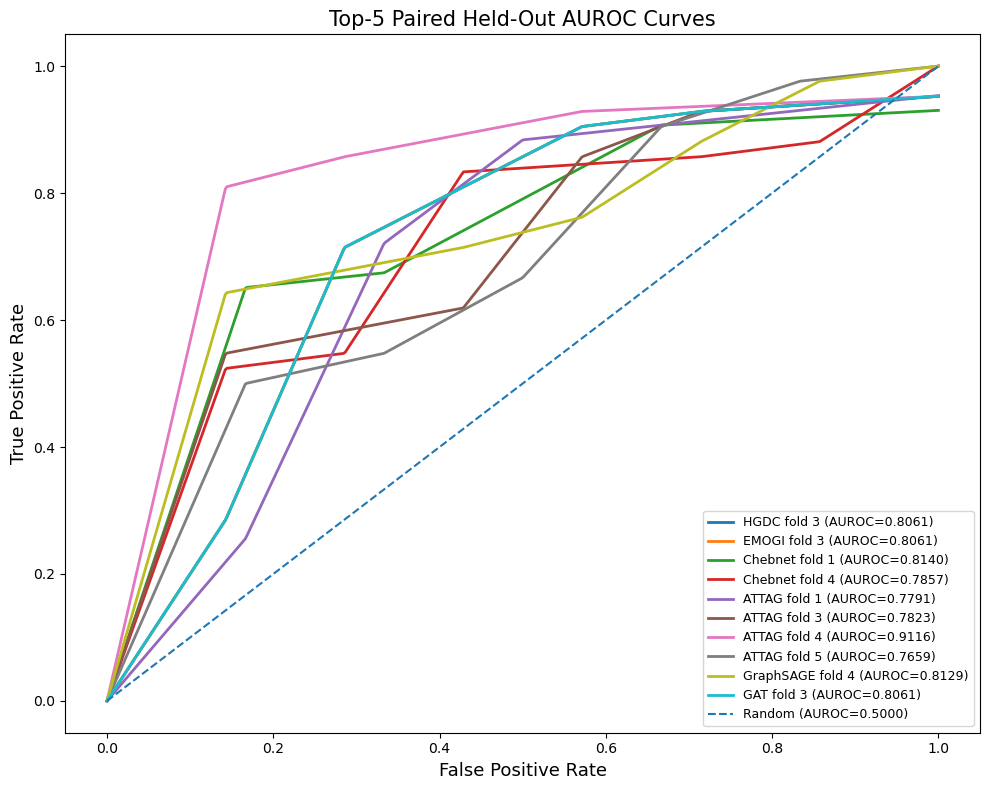

Saved: results/gene_prediction/12_model_heldout_benchmark/top5_heldout_AUROC_5folds.png


In [32]:
if (not PLOT_ONLY_IF_ATTAG_BEST) or ATTAG_IS_BEST_BOTH:
    plt.figure(figsize=(10, 8))
    fpr_grid = np.linspace(0, 1, 500)

    for row in top5_curve_results:
        fpr = np.asarray(row["fpr"], dtype=float)
        tpr = np.asarray(row["tpr"], dtype=float)
        valid = np.isfinite(fpr) & np.isfinite(tpr)
        fpr, tpr = fpr[valid], tpr[valid]
        order = np.argsort(fpr)
        fpr, tpr = fpr[order], tpr[order]
        fpr_u, idx = np.unique(fpr, return_index=True)
        tpr_u = tpr[idx]
        if len(fpr_u) >= 2:
            tpr_i = np.interp(fpr_grid, fpr_u, tpr_u)
            plt.plot(
                fpr_grid, tpr_i, linewidth=2,
                label=f"{row['Model']} fold {row['Fold']+1} (AUROC={row['AUROC']:.4f})"
            )

    plt.plot([0, 1], [0, 1], "--", linewidth=1.5, label="Random (AUROC=0.5000)")
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title("Top-5 Paired Held-Out AUROC Curves", fontsize=15)
    plt.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    roc_path = os.path.join(OUTPUT_DIR, f"top5_heldout_AUROC_{N_FOLDS_TOTAL}folds.png")
    plt.savefig(roc_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {roc_path}")
else:
    print("Skipping AUROC curve plot because ATTAG is not best on both mean AUROC and mean AUPRC.")

## 12. Plot top-5 paired AUPRC curves — only if ATTAG is best on both metrics

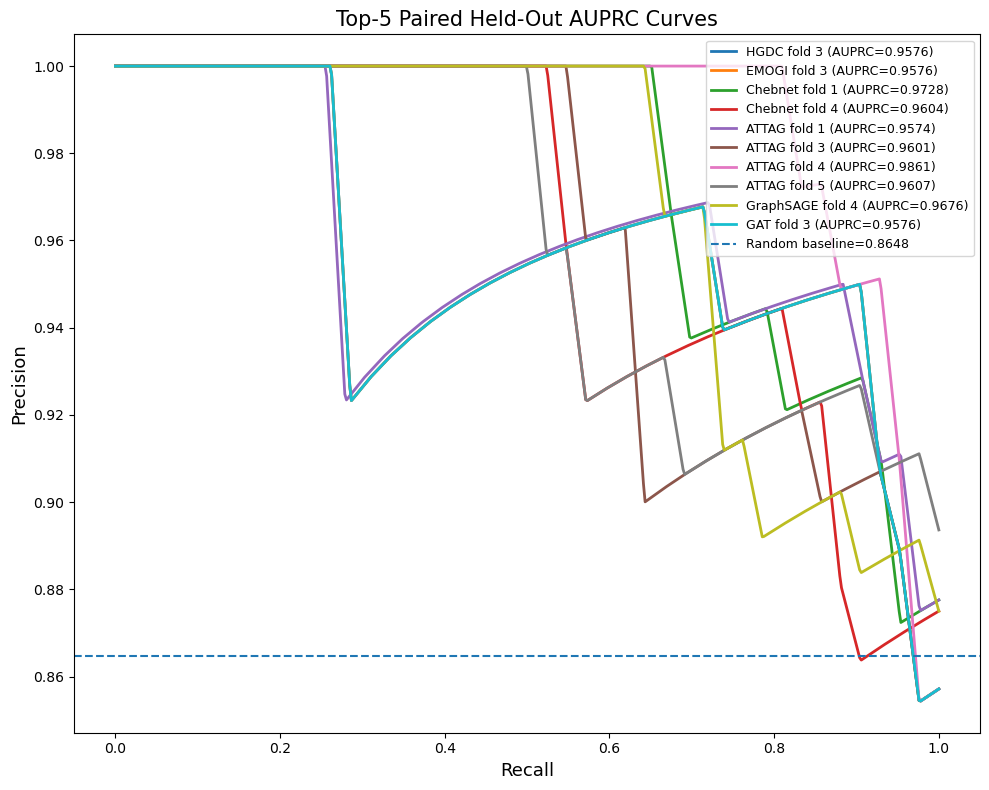

Saved: results/gene_prediction/12_model_heldout_benchmark/top5_heldout_AUPRC_5folds.png


In [33]:
if (not PLOT_ONLY_IF_ATTAG_BEST) or ATTAG_IS_BEST_BOTH:
    plt.figure(figsize=(10, 8))
    recall_grid = np.linspace(0, 1, 500)

    for row in top5_curve_results:
        recall = np.asarray(row["recall"], dtype=float)
        precision = np.asarray(row["precision"], dtype=float)
        valid = np.isfinite(recall) & np.isfinite(precision)
        recall, precision = recall[valid], precision[valid]
        order = np.argsort(recall)
        recall, precision = recall[order], precision[order]
        recall_u, idx = np.unique(recall, return_index=True)
        precision_u = precision[idx]
        if len(recall_u) >= 2:
            precision_i = np.interp(recall_grid, recall_u, precision_u)
            plt.plot(
                recall_grid, precision_i, linewidth=2,
                label=f"{row['Model']} fold {row['Fold']+1} (AUPRC={row['AUPRC']:.4f})"
            )

    baseline = float(np.mean(y_np[labeled_idx]))
    plt.axhline(baseline, linestyle="--", linewidth=1.5, label=f"Random baseline={baseline:.4f}")
    plt.xlabel("Recall", fontsize=13)
    plt.ylabel("Precision", fontsize=13)
    plt.title("Top-5 Paired Held-Out AUPRC Curves", fontsize=15)
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    pr_path = os.path.join(OUTPUT_DIR, f"top5_heldout_AUPRC_{N_FOLDS_TOTAL}folds.png")
    plt.savefig(pr_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: {pr_path}")
else:
    print("Skipping AUPRC curve plot because ATTAG is not best on both mean AUROC and mean AUPRC.")

## 13. Benchmark summary plot

The summary plot is intentionally separate from the ROC/PR-curve condition so that the numerical comparison remains visible even when ATTAG is not best on both metrics.

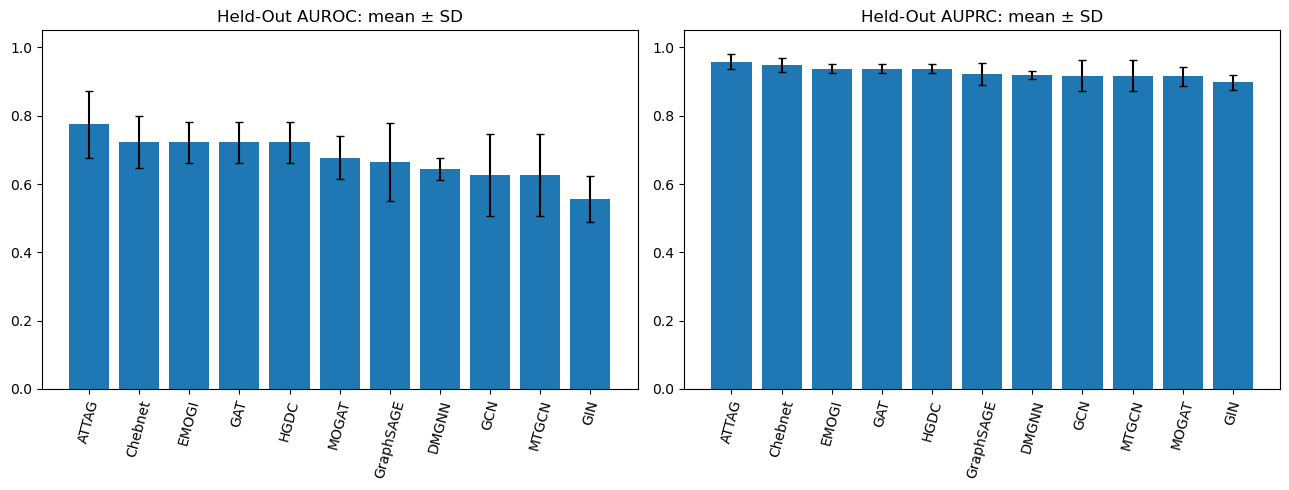

Saved: results/gene_prediction/12_model_heldout_benchmark/12_model_heldout_summary.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_df = summary_df.copy()
plot_df = plot_df.sort_values("AUROC_mean", ascending=False)

axes[0].bar(plot_df["Model"], plot_df["AUROC_mean"], yerr=plot_df["AUROC_std"], capsize=3)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Held-Out AUROC: mean ± SD")
axes[0].tick_params(axis="x", rotation=75)

plot_df2 = summary_df.sort_values("AUPRC_mean", ascending=False)
axes[1].bar(plot_df2["Model"], plot_df2["AUPRC_mean"], yerr=plot_df2["AUPRC_std"], capsize=3)
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Held-Out AUPRC: mean ± SD")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
summary_fig_path = os.path.join(OUTPUT_DIR, "12_model_heldout_summary.png")
plt.savefig(summary_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {summary_fig_path}")

## 14. Recover a representative ATTAG model for interpretation

The interpretation stage is run only when ATTAG satisfies the requested dual-best condition. The representative fold is selected by the highest paired mean of AUROC and AUPRC among ATTAG's successful folds.

In [35]:
if ATTAG_IS_BEST_BOTH:
    ATTAG_folds = success_df[success_df["Model"] == "ATTAG"].copy()
    ATTAG_folds["PairScore"] = (ATTAG_folds["AUROC"] + ATTAG_folds["AUPRC"]) / 2
    representative = ATTAG_folds.sort_values("PairScore", ascending=False).iloc[0]
    rep_fold_id = int(representative["Fold"])
    rep_fs = next(fs for fs in fold_splits if fs["fold_id"] == rep_fold_id)

    print(f"Representative ATTAG fold: {rep_fold_id + 1}")
    print(f"AUROC={representative['AUROC']:.6f}, AUPRC={representative['AUPRC']:.6f}")

    rep_result = run_one_model_fold("ATTAG", rep_fs, verbose=True)
    ATTAG_model = rep_result["model"]
    ATTAG_scores = rep_result["scores"]
else:
    print("Skipping ATTAG interpretation because ATTAG is not best on both metrics.")

Representative ATTAG fold: 4
AUROC=0.911565, AUPRC=0.986084


ATTAG | fold 4/5:   0%|          | 0/100 [00:00<?, ?epoch/s]

## 15. Compute leakage-safe ATTAG node-feature saliency

Saliency is computed from the representative ATTAG model. It is an interpretation step, not a performance metric. The default uses the absolute gradient of the mean validation-node logit with respect to the input features.

In [36]:
if ATTAG_IS_BEST_BOTH:
    g_int = graph_base.to(device)
    feat_int = g_int.ndata["feat"].detach().clone().to(device)
    feat_int.requires_grad_(True)

    ATTAG_model.eval()
    ATTAG_model.zero_grad(set_to_none=True)
    raw = ATTAG_model(g_int, feat_int)
    logits_int = normalize_binary_logits(raw, len(node_names))
    objective = logits_int[rep_fs["val_mask"].to(device)].mean()
    objective.backward()

    relevance_scores = feat_int.grad.detach().abs().cpu()
    gene_relevance = relevance_scores.sum(dim=1).numpy()

    print("Relevance matrix:", tuple(relevance_scores.shape))
    print("Top salient genes:")
    for idx in np.argsort(-gene_relevance)[:20]:
        print(f"  {node_names[idx]:20s} {gene_relevance[idx]:.6f}")
else:
    print("Skipping saliency computation.")

Relevance matrix: (1801, 128)
Top salient genes:
  ABI2                 35.539894
  ACTA2                17.841053
  ACAP1                14.318771
  ACTB                 13.177777
  ABL1                 9.807561
  ADIPOR2              7.496589
  ACTG1                5.164950
  ACVR1                5.093630
  AKT2                 4.978392
  ANAPC4               3.845702
  ANXA2                3.054906
  ANAPC2               2.593768
  ASAP1                2.502373
  ABI1                 2.474787
  BCL6                 2.238997
  CAMK2G               2.223853
  ACTR10               2.039074
  ACVR2B               2.027492
  ADAM10               1.958233
  ANK1                 1.865163


## 16. Build a cluster-first multilevel Sankey for ATTAG

The Sankey follows the requested biological structure:

**Cluster → salient gene → high-relevance neighbor → neighbor cluster**.

Only originally labeled genes or external candidates are used for visualization; external membership is not treated as ground truth. Clusters are derived reproducibly from saliency vectors using KMeans. The figure is exported as both interactive HTML and PNG when Kaleido is available.

In [43]:
def hex_to_rgba(hex_color, alpha=0.45):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"


def build_clusterfirst_sankey(
    graph,
    node_names,
    relevance_scores,
    output_dir,
    top_genes=100,
    top_neighbors=5,
    n_clusters=12,
):
    os.makedirs(output_dir, exist_ok=True)

    rel = relevance_scores.numpy() if torch.is_tensor(relevance_scores) else np.asarray(relevance_scores)
    gene_score = rel.sum(axis=1)
    top_idx = np.argsort(-gene_score)[:min(top_genes, len(node_names))]

    # KMeans requires at least n_clusters samples.
    k = min(n_clusters, len(top_idx))
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    cluster_labels = km.fit_predict(rel[top_idx])
    idx_to_cluster = {int(idx): int(c) for idx, c in zip(top_idx, cluster_labels)}

    palette = plt.cm.tab20(np.linspace(0, 1, max(k, 1)))
    cluster_colors = {}
    for c in range(k):
        rgb = tuple(int(v * 255) for v in palette[c][:3])
        cluster_colors[c] = f"rgb{rgb}"

    label_to_idx = {}
    labels = []
    colors = []
    sources, targets, values, link_colors = [], [], [], []
    seen_edges = set()

    def add_node(label, color):
        if label not in label_to_idx:
            label_to_idx[label] = len(labels)
            labels.append(label)
            colors.append(color)
        return label_to_idx[label]

    # Cluster -> gene -> neighbor -> neighbor cluster.
    for gene_idx in top_idx:
        gene = node_names[int(gene_idx)]
        c = idx_to_cluster[int(gene_idx)]
        c_label = f"Cluster {c}"
        c_idx = add_node(c_label, cluster_colors[c])
        g_idx = add_node(gene, cluster_colors[c])

        if (c_idx, g_idx) not in seen_edges:
            sources.append(c_idx); targets.append(g_idx); values.append(1.0)
            link_colors.append(hex_to_rgba(cluster_colors[c].replace("rgb", "").strip("()"), 0.45) if False else "rgba(120,120,120,0.35)")
            seen_edges.add((c_idx, g_idx))

        nbrs = graph.successors(int(gene_idx)).tolist()
        nbrs = [n for n in nbrs if n != gene_idx and n in idx_to_cluster]
        nbrs = sorted(nbrs, key=lambda n: gene_score[n], reverse=True)[:top_neighbors]

        for nbr in nbrs:
            nbr_name = node_names[int(nbr)]
            nbr_c = idx_to_cluster[int(nbr)]
            n_idx = add_node(nbr_name, cluster_colors[nbr_c])
            nc_label = f"nCluster {nbr_c}"
            nc_idx = add_node(nc_label, cluster_colors[nbr_c])
            w = float(max(gene_score[int(nbr)], 1e-8))

            if (g_idx, n_idx) not in seen_edges:
                sources.append(g_idx); targets.append(n_idx); values.append(w)
                link_colors.append("rgba(160,160,160,0.40)")
                seen_edges.add((g_idx, n_idx))
            if (n_idx, nc_idx) not in seen_edges:
                sources.append(n_idx); targets.append(nc_idx); values.append(w)
                link_colors.append("rgba(100,100,100,0.50)")
                seen_edges.add((n_idx, nc_idx))

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=18,
            thickness=24,
            line=dict(color="black", width=0.4),
            label=labels,
            color=colors,
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=link_colors,
        ),
    )])

    fig.update_layout(
        title="ATTAG Saliency-Guided Cluster-First Gene Neighbor Sankey",
        font_size=13,
        width=900,
        height=max(1000, 18 * len(labels)),
        margin=dict(l=20, r=20, t=60, b=20),
    )

    html_path = os.path.join(output_dir, "ATTAG_clusterfirst_multilevel_sankey.html")
    fig.write_html(html_path)
    print(f"Saved interactive Sankey: {html_path}")

    png_path = os.path.join(output_dir, "ATTAG_clusterfirst_multilevel_sankey.png")
    try:
        fig.write_image(png_path, scale=2)
        print(f"Saved Sankey PNG: {png_path}")
    except Exception as exc:
        print(f"PNG export skipped: {exc}")
        print("Install Kaleido if static Plotly export is needed: pip install kaleido")

    return fig

if ATTAG_IS_BEST_BOTH:
    sankey_fig = build_clusterfirst_sankey(
        graph_base.cpu(),
        node_names,
        relevance_scores,
        os.path.join(OUTPUT_DIR, "sankey"),
        top_genes=SANKEY_TOP_GENES,
        top_neighbors=SANKEY_TOP_NEIGHBORS,
        n_clusters=SANKEY_N_CLUSTERS,
    )
    sankey_fig.show()
else:
    print("Skipping Sankey because ATTAG is not best on both mean AUROC and mean AUPRC.")

Saved interactive Sankey: results/gene_prediction/12_model_heldout_benchmark/sankey/ATTAG_clusterfirst_multilevel_sankey.html
Saved Sankey PNG: results/gene_prediction/12_model_heldout_benchmark/sankey/ATTAG_clusterfirst_multilevel_sankey.png


## 17. External candidate ranking (OnGene/OncoKB) — separate from ground truth

The external list is used only to identify candidate genes among originally unlabeled nodes. This prevents the earlier contamination where an external candidate could silently become a confirmed driver label.

In [44]:
# Use the representative ATTAG scores when available; otherwise report the top model's fold-level candidates.
if ATTAG_IS_BEST_BOTH:
    candidate_scores = ATTAG_scores
    candidate_model_name = "ATTAG"
else:
    candidate_scores = None
    candidate_model_name = None

if candidate_scores is not None:
    candidate_idx = np.where(reference_candidate_mask)[0]
    candidate_rows = sorted(
        [
            {
                "Gene": node_names[i],
                "Model": candidate_model_name,
                "Score": float(candidate_scores[i]),
                "OriginalLabel": int(y_np[i]),
            }
            for i in candidate_idx
        ],
        key=lambda r: r["Score"],
        reverse=True,
    )
    candidate_path = os.path.join(OUTPUT_DIR, f"{REFERENCE_NAME}_candidates_ranked_ATTAG.csv")
    pd.DataFrame(candidate_rows).to_csv(candidate_path, index=False)
    print(f"Saved candidate ranking: {candidate_path}")
    print(pd.DataFrame(candidate_rows).head(25).to_string(index=False))
else:
    print("Candidate ranking skipped because the requested ATTAG dual-best condition was not met.")

Saved candidate ranking: results/gene_prediction/12_model_heldout_benchmark/OnGene_candidates_ranked_ATTAG.csv
   Gene Model    Score  OriginalLabel
  PRKCA ATTAG 1.000000             -1
  IGF1R ATTAG 1.000000             -1
   GNAS ATTAG 1.000000             -1
 EEF1A1 ATTAG 1.000000             -1
  RPL23 ATTAG 1.000000             -1
   CDK8 ATTAG 1.000000             -1
   RHOA ATTAG 1.000000             -1
  HSPA5 ATTAG 1.000000             -1
    BOC ATTAG 0.999999             -1
 TRIM28 ATTAG 0.999998             -1
  YWHAZ ATTAG 0.999997             -1
  YWHAG ATTAG 0.999993             -1
   EGFR ATTAG 0.999990             -1
   FDPS ATTAG 0.999986             -1
PPP2R1A ATTAG 0.999979             -1
   VAV2 ATTAG 0.999945             -1
 SREBF1 ATTAG 0.999897             -1
   YAP1 ATTAG 0.999896             -1
   CBX8 ATTAG 0.999847             -1
  CCNB1 ATTAG 0.999841             -1
   PAK1 ATTAG 0.999813             -1
   TCP1 ATTAG 0.999695             -1
   EZH2 ATTAG 0

## 18. Final audit and output inventory

In [45]:
# Final assertions.
assert len(results_df) == len(MODEL_CHOICES) * N_FOLDS_TOTAL
assert set(results_df["Model"]) == set(MODEL_CHOICES)
assert np.all(results_df.loc[results_df["Status"] == "success", "AUROC"].between(0, 1))
assert np.all(results_df.loc[results_df["Status"] == "success", "AUPRC"].between(0, 1))

print("=" * 90)
print("FINAL BENCHMARK CHECK")
print("=" * 90)
print(f"Models evaluated: {len(MODEL_CHOICES)}")
print(f"Folds per model: {N_FOLDS_TOTAL}")
print(f"Expected model-fold records: {len(MODEL_CHOICES) * N_FOLDS_TOTAL}")
print(f"Actual records: {len(results_df)}")
print(f"Top paired curves retained: {len(top5_curve_results)}")
print(f"ATTAG best on both metrics: {ATTAG_IS_BEST_BOTH}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

print("Files currently in output directory:")
for root, dirs, files in os.walk(OUTPUT_DIR):
    for name in sorted(files):
        print("  ", os.path.join(root, name))

FINAL BENCHMARK CHECK
Models evaluated: 12
Folds per model: 5
Expected model-fold records: 60
Actual records: 60
Top paired curves retained: 10
ATTAG best on both metrics: True
Output directory: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG/attag/results/gene_prediction/12_model_heldout_benchmark
Files currently in output directory:
   results/gene_prediction/12_model_heldout_benchmark/12_model_heldout_summary.png
   results/gene_prediction/12_model_heldout_benchmark/OnGene_candidates_ranked_ATTAG.csv
   results/gene_prediction/12_model_heldout_benchmark/all_model_fold_results_20folds.csv
   results/gene_prediction/12_model_heldout_benchmark/all_model_fold_results_5folds.csv
   results/gene_prediction/12_model_heldout_benchmark/model_comparison_summary_20folds.csv
   results/gene_prediction/12_model_heldout_benchmark/model_comparison_summary_5folds.csv
   results/gene_prediction/12_model_heldout_benchmark/top5_heldout_AUPRC_5folds.png
   results/

## Notes on the evaluation design

- **Primary AUROC/AUPRC:** held-out labeled nodes only.
- **Training loss:** training labeled nodes only.
- **Unlabeled genes:** never converted into confirmed ground truth by external-list membership.
- **External OnGene/OncoKB list:** candidate/prior information only.
- **Curve selection:** top five paired model-fold evaluations by `(AUROC + AUPRC)/2`.
- **Plot condition:** ROC/PR and Sankey plots are generated only if ATTAG has the highest mean AUROC **and** highest mean AUPRC, as requested.
- **Sankey:** saliency-guided and graph-neighbor based; it is an interpretation visualization, not an evaluation metric.